# Ar-41 Decay Analysis with Charge Matching

Combines the ar41_decay analysis (light-only, fixed-peak fprompt) with charge hit
positions read directly from the reflow HDF5 files via h5flow references.

**Runs:** 979 (decay, HV on) and 980 (decay, HV off)  
**Goal:** Understand where in the detector different fprompt-energy populations originate.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
import datetime, pytz

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
# DUNE plot style
import sys; sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "..", "utils"))
from dune_plot import apply_dune_style, dune_label
apply_dune_style()

In [3]:
from dtg_utils import (
    thd_correct, TRAP_NAME_MAP, sum_to_traps,
    get_trap_indices, reject_saturation,
    compute_fprompt_fixed, detect_pileup_rising_tail, calibrate_energy_mev,
    get_charge_hits_for_light_events, discover_files,
    SAT_THRESHOLD, PEAK_TICK_FIXED, PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT,
    LCM_ENERGY_NORM, ENERGY_SCALE, N_MODULES,
    REFLOW_DIR, AR41_HALF_LIFE,
)

acl_idx, acl_tpc = get_trap_indices("acl")
lcm_idx, lcm_tpc = get_trap_indices("lcm")
print(f"ACL traps (excl. TPC 6): {len(acl_idx)},  LCM traps (excl. TPC 6): {len(lcm_idx)}")

ACL traps (excl. TPC 6): 28,  LCM traps (excl. TPC 6): 28


## Configuration

In [4]:
DETECTOR   = "lcm"    # "lcm" or "acl"
CHUNK_SIZE = 300
N_FILES    = 20       # number of run-980 files to process (None = all)
BIN_WIDTH  = 30       # minutes — for time histograms

# Ar-41 signal region
AR41_FP_MIN = 0.65
AR41_FP_MAX = 0.9
AR41_EN_MIN = 1.0   # MeV
AR41_EN_MAX = 3.8   # MeV

REGIONS = {
    "Ar41 signal": {"fp": (AR41_FP_MIN, AR41_FP_MAX), "en": (AR41_EN_MIN, AR41_EN_MAX)},
    "High fprompt":{"fp": (0.65, 0.9),                 "en": (0.1, 1)},
    "Low fprompt": {"fp": (0.25, 0.45),                 "en": (0.1, 2.4)},
    "High energy": {"fp": (0.65, 0.9),                 "en": (4, 9)},
}

REGION_COLORS = {
    "Ar41 signal":  "tab:blue",
    "High fprompt": "tab:red",
    "Low fprompt":  "tab:green",
    "High energy":  "tab:orange",
}

# --- Spark-free time windows (from ar41_decay.ipynb rate analysis) ---
chicago = pytz.timezone("America/Chicago")
DTG_OFF = datetime.datetime(2025, 12, 12, 17, 36, 0, tzinfo=chicago)
WINDOW_HALF = datetime.timedelta(minutes=2)

good_windows = [
    ("t069m",  datetime.datetime(2025, 12, 12, 18, 45, 0, tzinfo=chicago)),
    ("t099m",  datetime.datetime(2025, 12, 12, 19, 15, 0, tzinfo=chicago)),
    ("t129m",  datetime.datetime(2025, 12, 12, 19, 45, 0, tzinfo=chicago)),
    ("t189m",  datetime.datetime(2025, 12, 12, 20, 45, 0, tzinfo=chicago)),
    ("t219m",  datetime.datetime(2025, 12, 12, 21, 15, 0, tzinfo=chicago)),
    ("t264m",  datetime.datetime(2025, 12, 12, 22,  0, 0, tzinfo=chicago)),
    ("t309m",  datetime.datetime(2025, 12, 12, 22, 45, 0, tzinfo=chicago)),
    ("t399m",  datetime.datetime(2025, 12, 13,  0, 15, 0, tzinfo=chicago)),
    ("t459m",  datetime.datetime(2025, 12, 13,  1, 15, 0, tzinfo=chicago)),
    ("t519m",  datetime.datetime(2025, 12, 13,  2, 15, 0, tzinfo=chicago)),
    ("t564m",  datetime.datetime(2025, 12, 13,  3,  0, 0, tzinfo=chicago)),
    ("t699m",  datetime.datetime(2025, 12, 13,  5, 15, 0, tzinfo=chicago)),
    ("t759m",  datetime.datetime(2025, 12, 13,  6, 15, 0, tzinfo=chicago)),
]

# Pre-compute window boundaries in unix ms for fast event-level filtering
good_window_bounds_ms = []
for label, centre in good_windows:
    lo = (centre - WINDOW_HALF).timestamp() * 1e3
    hi = (centre + WINDOW_HALF).timestamp() * 1e3
    good_window_bounds_ms.append((lo, hi))

## Discover decay reflow files

In [5]:
# Discover reflow files
files_979_all = discover_files(REFLOW_DIR, run=979)
files_980_all = discover_files(REFLOW_DIR, run=980)
print(f"Run 979 (decay, HV on):  {len(files_979_all)} reflow files")
print(f"Run 980 (decay, HV off): {len(files_980_all)} reflow files")

# Read first-event timestamp from each run-979 file to match against good_windows
# (fast: single scalar read per file)
print("\nReading timestamps from run-979 reflow files ...")
file_t0_979 = {}  # path → first-event timestamp (Chicago datetime)
for i, path in enumerate(files_979_all):
    if i % 50 == 0:
        print(f"  {i}/{len(files_979_all)} ...", flush=True)
    try:
        with h5py.File(path, "r") as h:
            t_ms = float(h["light/events/data"]["utime_ms"][0, 0])
        t_chi = datetime.datetime.fromtimestamp(t_ms / 1e3, tz=chicago)
        file_t0_979[path] = t_chi
    except Exception as e:
        print(f"  skip {os.path.basename(path)}: {e}")

print(f"Timestamped {len(file_t0_979)}/{len(files_979_all)} run-979 files")

# Select run-979 files whose first event falls in a spark-free window
selected_979 = []
for label, centre in good_windows:
    lo = centre - WINDOW_HALF
    hi = centre + WINDOW_HALF
    matched = sorted(
        [p for p, t in file_t0_979.items() if lo <= t < hi],
        key=lambda p: file_t0_979[p]
    )
    dt_min = (centre - DTG_OFF).total_seconds() / 60
    print(f"  {label}  Δt={dt_min:+7.0f} min  →  {len(matched)} reflow files")
    selected_979.extend(matched)

selected_979 = sorted(set(selected_979), key=lambda p: file_t0_979[p])

# Run 980: subsample (no good_windows filtering — different run)
if N_FILES is not None:
    idx_980 = np.linspace(0, len(files_980_all) - 1, min(N_FILES, len(files_980_all)), dtype=int)
    selected_980 = [files_980_all[i] for i in idx_980]
else:
    selected_980 = files_980_all

all_selected = selected_979 + selected_980
print(f"\nSelected: {len(selected_979)} from 979 (spark-free windows), "
      f"{len(selected_980)} from 980 = {len(all_selected)} total")

Run 979 (decay, HV on):  190 reflow files
Run 980 (decay, HV off): 98 reflow files

Reading timestamps from run-979 reflow files ...
  0/190 ...
  50/190 ...
  100/190 ...
  150/190 ...
Timestamped 190/190 run-979 files
  t069m  Δt=    +69 min  →  1 reflow files
  t099m  Δt=    +99 min  →  1 reflow files
  t129m  Δt=   +129 min  →  0 reflow files
  t189m  Δt=   +189 min  →  0 reflow files
  t219m  Δt=   +219 min  →  2 reflow files
  t264m  Δt=   +264 min  →  2 reflow files
  t309m  Δt=   +309 min  →  2 reflow files
  t399m  Δt=   +399 min  →  0 reflow files
  t459m  Δt=   +459 min  →  0 reflow files
  t519m  Δt=   +519 min  →  0 reflow files
  t564m  Δt=   +564 min  →  1 reflow files
  t699m  Δt=   +699 min  →  0 reflow files
  t759m  Δt=   +759 min  →  2 reflow files

Selected: 11 from 979 (spark-free windows), 20 from 980 = 31 total


## Process light waveforms + read charge hits

For each file: process light (fixed-peak fprompt, rising-tail pileup, saturation rejection),
then read charge hits from the same flow file via h5flow references.

In [6]:
def process_file_with_charge(path, chunk_size=CHUNK_SIZE):
    """
    Process one reflow HDF5 file:
    1. Light: fixed-peak fprompt, rising-tail pileup, saturation rejection
    2. Charge: read hits via h5flow references for good events
    
    Returns dict with per-event light arrays and charge hit data.
    """
    fp_acl, en_acl, np_acl = [], [], []
    fp_lcm, en_lcm, np_lcm = [], [], []
    ev_indices = []  # event indices of good events
    timestamps = []  # unix timestamp per event

    with h5py.File(path, "r") as h:
        # Read timestamps
        utime_ms = h["light/events/data"]["utime_ms"]
        n_total = len(utime_ms)
        wvfm_ds = h["/light/wvfm/data"]["samples"]

        for start in range(0, n_total, chunk_size):
            stop = min(start + chunk_size, n_total)

            raw = wvfm_ds[start:stop, :, :, :500]
            samples = thd_correct(raw.astype(np.float32)); del raw
            saturated = reject_saturation(samples, SAT_THRESHOLD)
            trap_wvfms = sum_to_traps(samples, TRAP_NAME_MAP).astype(np.float32); del samples

            trap_fprompts, trap_integrals = compute_fprompt_fixed(trap_wvfms, PEAK_TICK_FIXED)
            n_peaks_traps = detect_pileup_rising_tail(
                trap_wvfms, PEAK_TICK_FIXED, PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT
            )
            del trap_wvfms

            good = ~saturated
            fp_acl.append(trap_fprompts[good][:, acl_idx])
            en_acl.append(trap_integrals[good][:, acl_idx])
            np_acl.append(n_peaks_traps[good][:, acl_idx])
            fp_lcm.append(trap_fprompts[good][:, lcm_idx])
            en_lcm.append(trap_integrals[good][:, lcm_idx])
            np_lcm.append(n_peaks_traps[good][:, lcm_idx])

            chunk_indices = np.arange(start, stop)[good]
            ev_indices.append(chunk_indices)

            # Timestamps for good events
            chunk_ts = utime_ms[start:stop, 0]  # first ADC's timestamp
            timestamps.append(chunk_ts[good])

    def cat(lst): return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)

    good_indices = np.concatenate(ev_indices) if ev_indices else np.array([], dtype=int)

    # Now read charge hits for all good light events
    charge_data = get_charge_hits_for_light_events(path, good_indices)

    return {
        "fprompt_acl": cat(fp_acl), "energy_acl": cat(en_acl), "n_peaks_acl": cat(np_acl),
        "fprompt_lcm": cat(fp_lcm), "energy_lcm": cat(en_lcm), "n_peaks_lcm": cat(np_lcm),
        "event_indices": good_indices,
        "timestamps": np.concatenate(timestamps) if timestamps else np.array([]),
        "charge_hits": charge_data["hits"],
        "charge_light_idx": charge_data["light_event_idx"],
        "charge_n_hits": charge_data["n_hits_per_event"],
    }

In [7]:
results = {}  # path -> result dict

for path in all_selected:
    fname = os.path.basename(path)
    print(f"Processing {fname} ...", end=" ", flush=True)
    try:
        results[path] = process_file_with_charge(path)
        r = results[path]
        n_ev = r["fprompt_acl"].shape[0] if r["fprompt_acl"].ndim == 2 else 0
        n_hits = len(r["charge_hits"])
        print(f"done  — {n_ev:,} events, {n_hits:,} charge hits")
    except Exception as e:
        print(f"FAILED: {e}")

total_events = sum(
    r["fprompt_acl"].shape[0] for r in results.values()
    if r["fprompt_acl"].ndim == 2
)
total_hits = sum(len(r["charge_hits"]) for r in results.values())
print(f"\nTotal: {total_events:,} events, {total_hits:,} charge hits across {len(results)} files")

Processing mpd_run_run2data_rctl_979_p8_v0p2.FLOW.hdf5 ... 

/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:199: RuntimeWarning: Mean of empty slice
  average_mean = np.nanmean(sorted_means[..., 1:3], axis=-1)
/global/u2/m/mnuland/backtracking/2x2_neutron_sources/DTG/light/dtg_utils.py:275: RuntimeWarning: divide by zero encountered in divide
  fprompt = fprompt_num / fprompt_den


done  — 4,601 events, 27,710 charge hits
Processing mpd_run_run2data_rctl_979_p58_v0p2.FLOW.hdf5 ... done  — 4,765 events, 26,758 charge hits
Processing mpd_run_run2data_rctl_979_p177_v0p2.FLOW.hdf5 ... done  — 3,717 events, 89,016 charge hits
Processing mpd_run_run2data_rctl_979_p179_v0p2.FLOW.hdf5 ... done  — 3,863 events, 50,579 charge hits
Processing mpd_run_run2data_rctl_979_p222_v0p2.FLOW.hdf5 ... FAILED: 'Unable to synchronously open object (component not found)'
Processing mpd_run_run2data_rctl_979_p223_v0p2.FLOW.hdf5 ... done  — 3,590 events, 52,420 charge hits
Processing mpd_run_run2data_rctl_979_p267_v0p2.FLOW.hdf5 ... done  — 3,299 events, 42,809 charge hits
Processing mpd_run_run2data_rctl_979_p269_v0p2.FLOW.hdf5 ... done  — 3,382 events, 48,875 charge hits
Processing mpd_run_run2data_rctl_979_p521_v0p2.FLOW.hdf5 ... FAILED: 'Unable to synchronously open object (component not found)'
Processing mpd_run_run2data_rctl_979_p714_v0p2.FLOW.hdf5 ... done  — 2,699 events, 41,240 

## Fprompt vs Energy — all events

Total trap-entries: 3,806,320
Clean (npe<=2, finite): 3,806,248


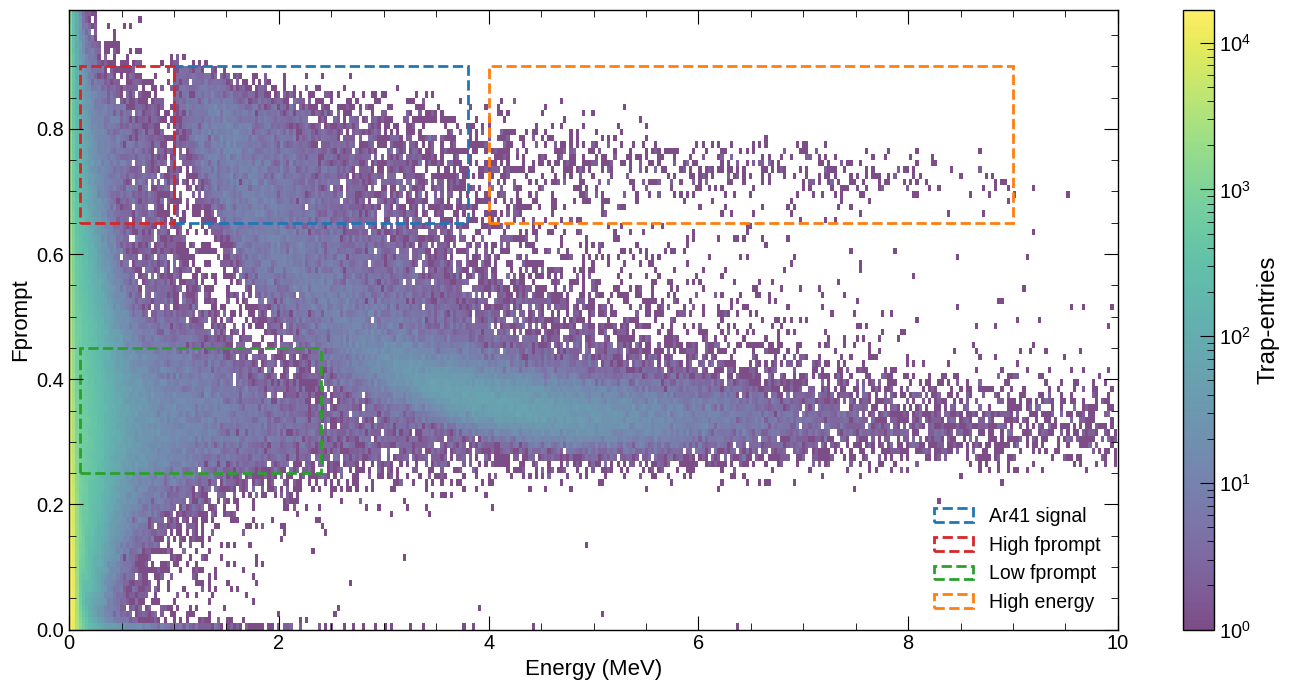

In [8]:
# Combine all light data
all_fp, all_en, all_npe = [], [], []
for r in results.values():
    fp = r[f"fprompt_{DETECTOR}"]
    en = r[f"energy_{DETECTOR}"]
    npe = r[f"n_peaks_{DETECTOR}"]
    if fp.ndim == 2:
        all_fp.append(fp.ravel())
        all_en.append(en.ravel())
        all_npe.append(npe.ravel())

all_fp = np.concatenate(all_fp)
all_en = np.concatenate(all_en)
all_npe = np.concatenate(all_npe)
all_en_mev = all_en / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
clean = np.isfinite(all_fp) & np.isfinite(all_en_mev) & (all_npe <= 2)

print(f"Total trap-entries: {len(all_fp):,}")
print(f"Clean (npe<=2, finite): {clean.sum():,}")

EN_BINS = np.arange(0, 10, 0.03)
FP_BINS = np.arange(0, 1, 0.01)

fig, ax = plt.subplots(figsize=(14, 7))
h = ax.hist2d(all_en_mev[clean], all_fp[clean], bins=[EN_BINS, FP_BINS],
              norm=LogNorm(), cmap="viridis", alpha=0.7)
plt.colorbar(h[3], ax=ax, label="Trap-entries")

for name, region in REGIONS.items():
    fp_lo, fp_hi = region["fp"]
    en_lo, en_hi = region["en"]
    rect = Rectangle((en_lo, fp_lo), en_hi - en_lo, fp_hi - fp_lo,
                      linewidth=2, edgecolor=REGION_COLORS[name],
                      facecolor="none", linestyle="--", label=name)
    ax.add_patch(rect)

ax.set_xlabel("Energy (MeV)", fontsize=16)
ax.set_ylabel("Fprompt", fontsize=16)
ax.set_xlim(0, 10)
ax.legend(fontsize=14, loc="lower right")
# ax.set_title(f"Decay data (979+980), {DETECTOR.upper()}, npe<=2", fontsize=13)
plt.tight_layout()
plt.show()

## Charge hit positions by fprompt-energy region

For events in each fprompt-energy region, find the associated charge hits
and plot their spatial distribution.

In [9]:
def in_region(fp, en_mev, region):
    """Boolean mask for trap-entries falling in a region."""
    fp_lo, fp_hi = region["fp"]
    en_lo, en_hi = region["en"]
    mask = np.isfinite(fp) & np.isfinite(en_mev)
    if fp_lo is not None: mask &= fp >= fp_lo
    if fp_hi is not None: mask &= fp < fp_hi
    if en_lo is not None: mask &= en_mev >= en_lo
    if en_hi is not None: mask &= en_mev < en_hi
    return mask


def find_event_indices_in_region(res, det, region):
    """Return event indices (within file) that have at least one trap in the region."""
    fp = res[f"fprompt_{det}"]
    en = res[f"energy_{det}"]
    npe = res[f"n_peaks_{det}"]
    en_mev = en / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
    trap_in = in_region(fp, en_mev, region) & (npe <= 2)
    event_in = trap_in.any(axis=1)
    return res["event_indices"][event_in]

In [10]:
# Collect charge hits per region across all files
charge_by_region = {name: [] for name in REGIONS}

for path, r in results.items():
    if len(r["charge_hits"]) == 0:
        continue

    for region_name, region in REGIONS.items():
        ev_idx = find_event_indices_in_region(r, DETECTOR, region)
        if len(ev_idx) == 0:
            continue

        # Find charge hits belonging to these events
        ev_set = set(ev_idx.tolist())
        hit_mask = np.array([int(li) in ev_set for li in r["charge_light_idx"]])
        if hit_mask.sum() == 0:
            continue

        hits = r["charge_hits"][hit_mask]
        charge_by_region[region_name].append(pd.DataFrame({
            "x": hits["x"],
            "y": hits["y"],
            "z": hits["z"],
            "Q": hits["Q"],
            "E": hits["E"],
            "file": os.path.basename(path),
        }))

# Merge
charge_dfs = {}
for name in REGIONS:
    if charge_by_region[name]:
        charge_dfs[name] = pd.concat(charge_by_region[name], ignore_index=True)
    else:
        charge_dfs[name] = pd.DataFrame()

print("Charge hits per region:")
for name, df in charge_dfs.items():
    print(f"  {name:20s}: {len(df):,} hits")

Charge hits per region:
  Ar41 signal         : 23,944 hits
  High fprompt        : 27,738 hits
  Low fprompt         : 257,400 hits
  High energy         : 1,497 hits


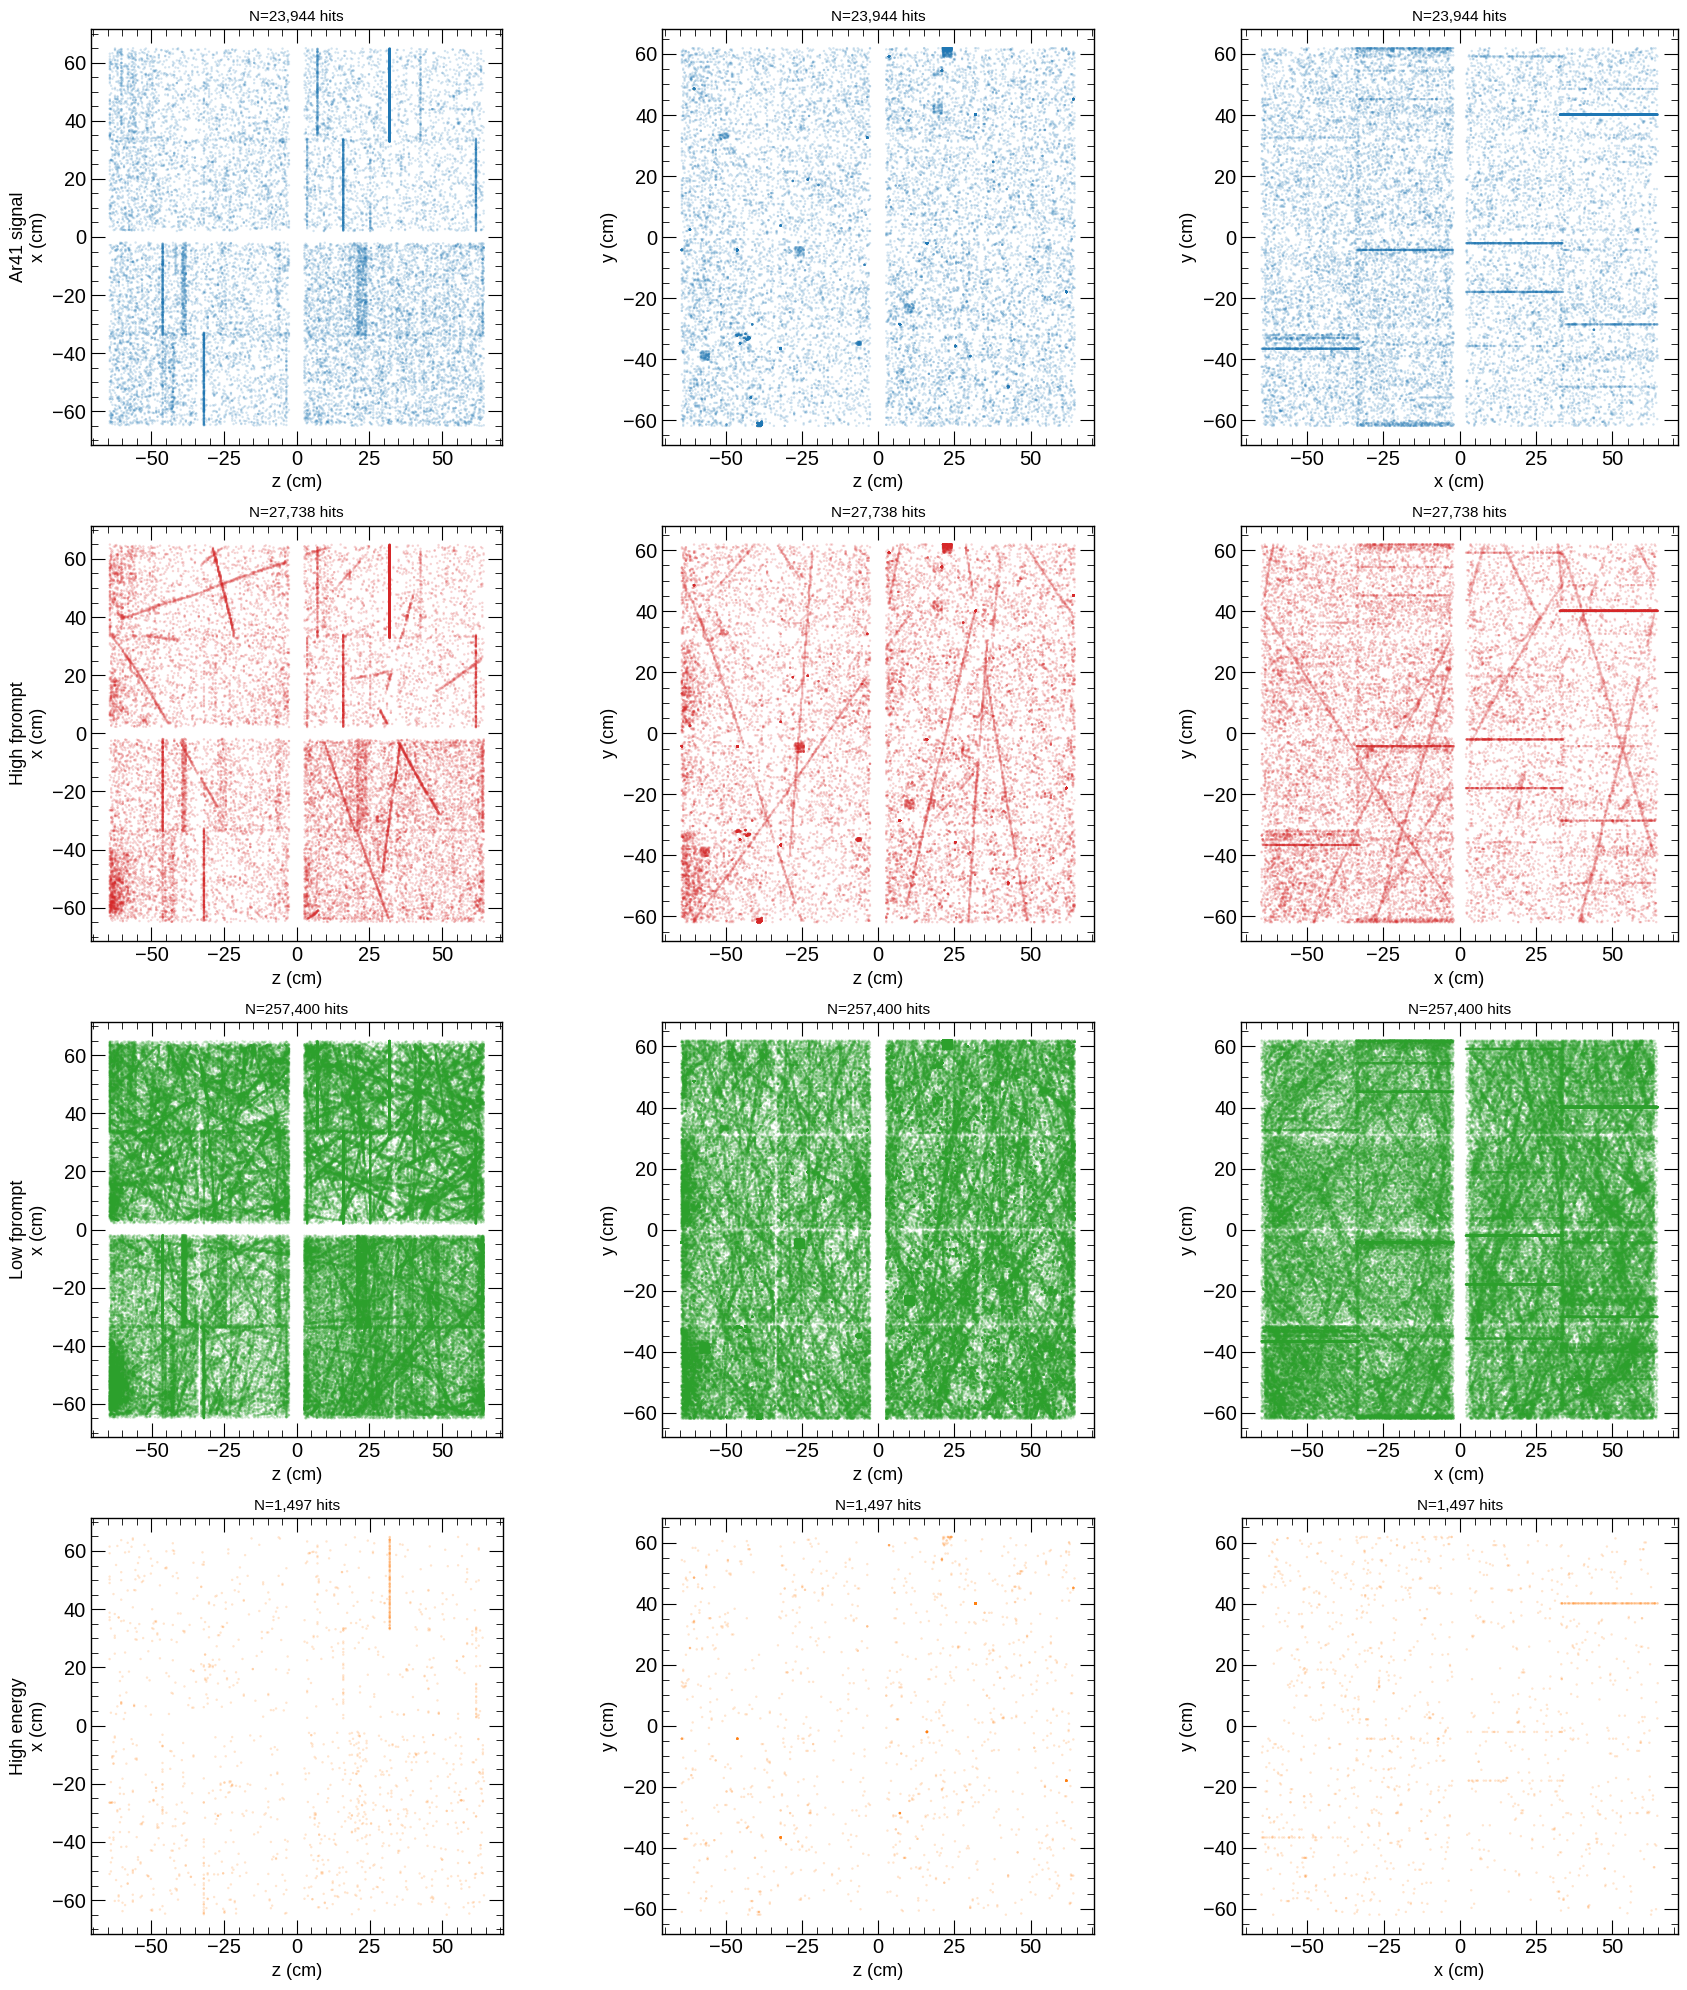

In [11]:
projections = [("z", "x", "z (cm)", "x (cm)"),
               ("z", "y", "z (cm)", "y (cm)"),
               ("x", "y", "x (cm)", "y (cm)")]

regions_to_plot = [name for name in REGIONS if len(charge_dfs.get(name, [])) > 0]

if not regions_to_plot:
    print("No charge hits in any region.")
else:
    fig, axes = plt.subplots(len(regions_to_plot), len(projections),
                             figsize=(6 * len(projections), 5 * len(regions_to_plot)),
                             squeeze=False)

    for i, region_name in enumerate(regions_to_plot):
        df = charge_dfs[region_name]
        color = REGION_COLORS[region_name]

        for j, (xc, yc, xl, yl) in enumerate(projections):
            ax = axes[i, j]
            ax.scatter(df[xc], df[yc], s=3, c=color, alpha=0.2, edgecolors="none")
            ax.set_xlabel(xl, fontsize=13)
            ax.set_ylabel(yl, fontsize=13)
            ax.tick_params(direction="in")
            ax.set_aspect("equal")
            if j == 0:
                ax.set_ylabel(f"{region_name}\n{yl}", fontsize=13)
            ax.set_title(f"N={len(df):,} hits", fontsize=11)

    plt.tight_layout()
    plt.show()

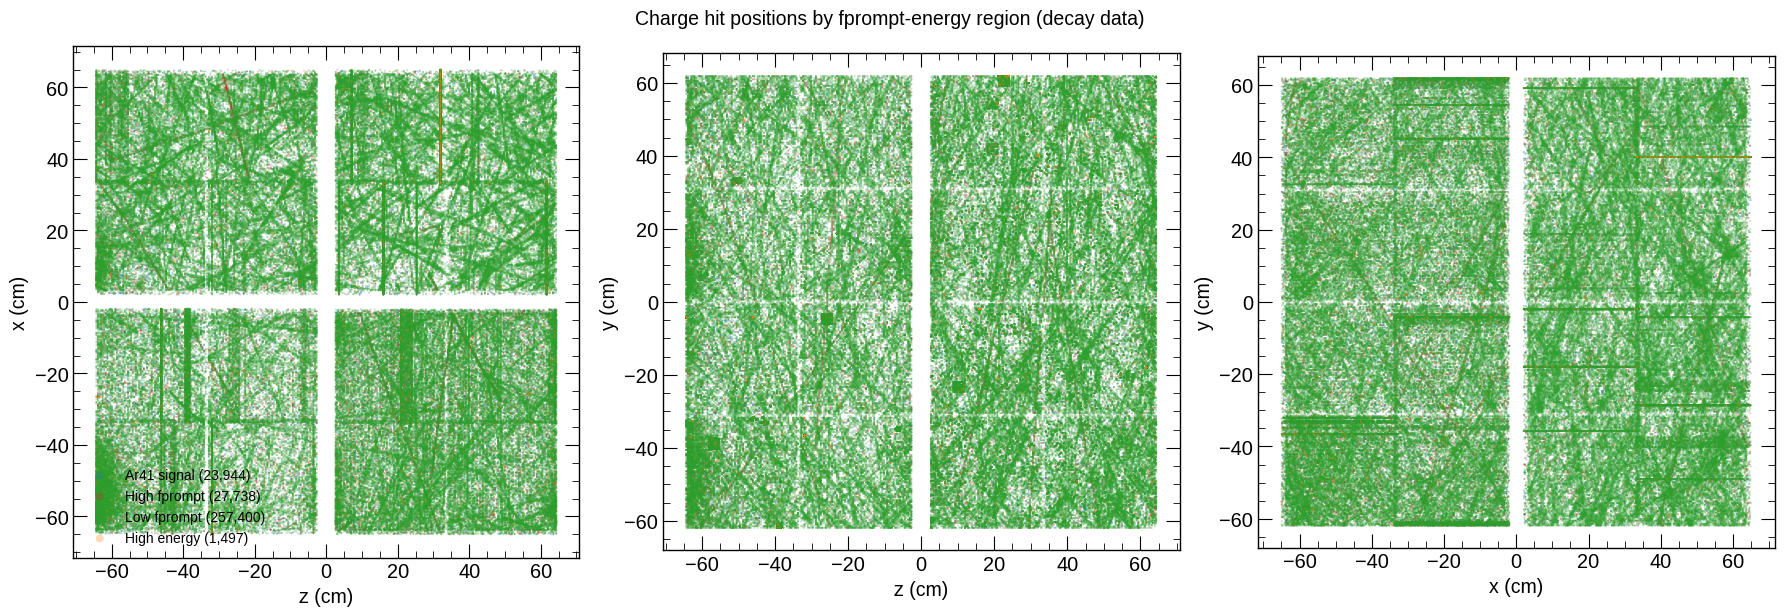

In [12]:
# All regions overlaid
if regions_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for region_name in regions_to_plot:
        df = charge_dfs[region_name]
        color = REGION_COLORS[region_name]
        for j, (xc, yc, xl, yl) in enumerate(projections):
            axes[j].scatter(df[xc], df[yc], s=2, c=color, alpha=0.3,
                            edgecolors="none", label=f"{region_name} ({len(df):,})")
            axes[j].set_xlabel(xl, fontsize=14)
            axes[j].set_ylabel(yl, fontsize=14)
            axes[j].tick_params(direction="in")
            axes[j].set_aspect("equal")

    axes[0].legend(fontsize=10, markerscale=4, loc="lower left")
    fig.suptitle("Charge hit positions by fprompt-energy region (decay data)", fontsize=14)
    plt.tight_layout()
    plt.show()

## Charge-matched vs unmatched fprompt-energy distributions

Charge-matched events:   1,968,591 clean trap-entries
No charge match events:  1,837,657 clean trap-entries


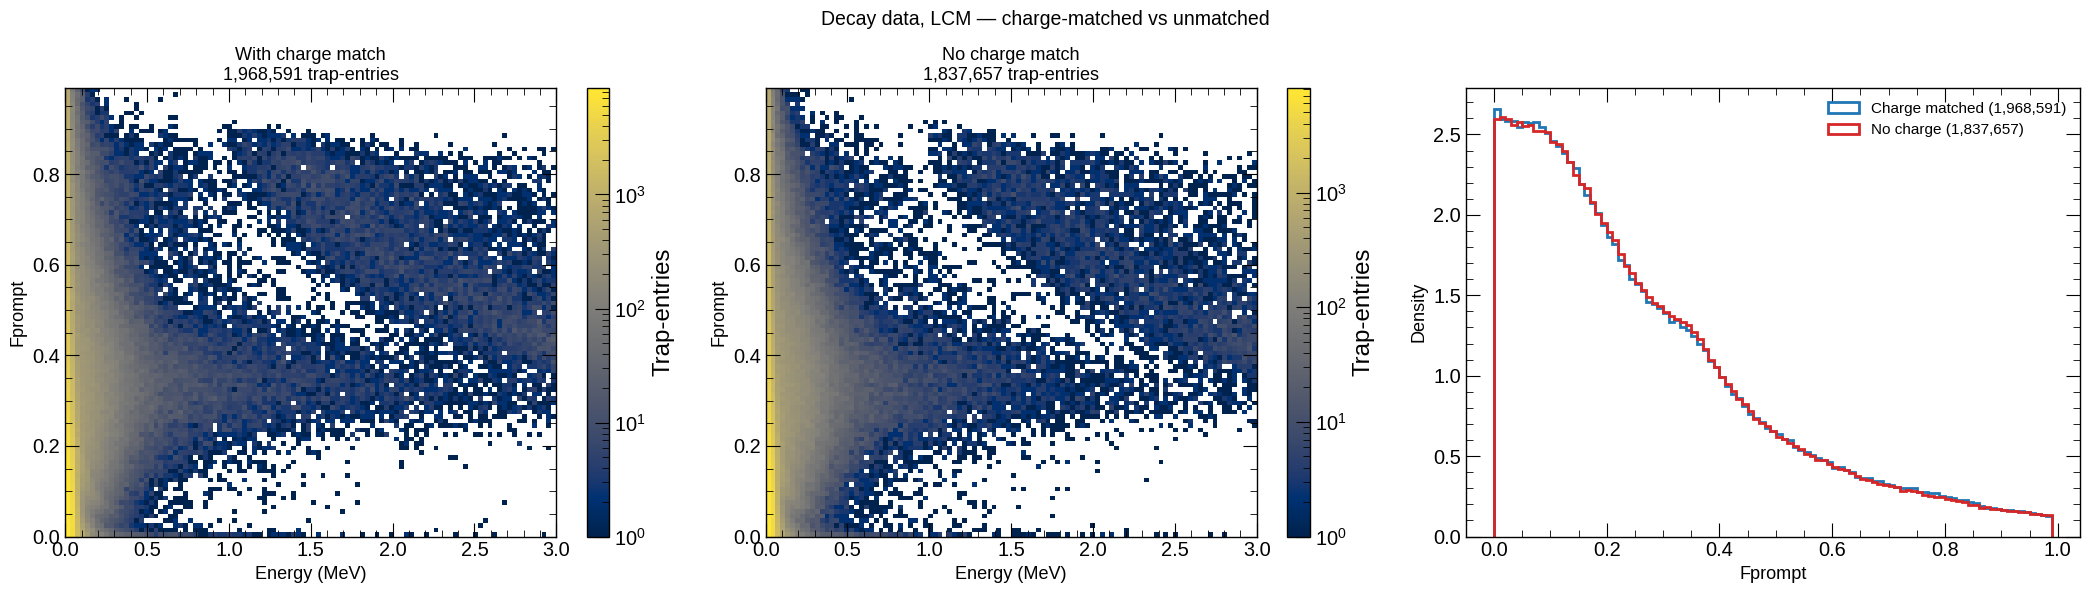

In [13]:
# Split events into charge-matched (>= 1 hit) vs no charge
fp_matched, en_matched, npe_matched = [], [], []
fp_unmatched, en_unmatched, npe_unmatched = [], [], []

for path, r in results.items():
    ev_idx = r["event_indices"]
    n_ev = len(ev_idx)
    if n_ev == 0:
        continue

    # Find which events have any charge hits
    if len(r["charge_light_idx"]) > 0:
        matched_lids = set(r["charge_light_idx"].tolist())
    else:
        matched_lids = set()

    has_charge = np.array([int(idx) in matched_lids for idx in ev_idx])

    fp  = r[f"fprompt_{DETECTOR}"]
    en  = r[f"energy_{DETECTOR}"]
    npe = r[f"n_peaks_{DETECTOR}"]

    fp_matched.append(fp[has_charge]);    en_matched.append(en[has_charge]);    npe_matched.append(npe[has_charge])
    fp_unmatched.append(fp[~has_charge]); en_unmatched.append(en[~has_charge]); npe_unmatched.append(npe[~has_charge])

def _cat(lst):
    return np.concatenate(lst, axis=0) if lst else np.array([]).reshape(0, 0)

fp_m  = _cat(fp_matched).ravel();   en_m  = _cat(en_matched).ravel();   npe_m  = _cat(npe_matched).ravel()
fp_u  = _cat(fp_unmatched).ravel(); en_u  = _cat(en_unmatched).ravel(); npe_u  = _cat(npe_unmatched).ravel()
en_m_mev = en_m / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
en_u_mev = en_u / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
clean_m = np.isfinite(fp_m) & np.isfinite(en_m_mev) & (npe_m <= 2)
clean_u = np.isfinite(fp_u) & np.isfinite(en_u_mev) & (npe_u <= 2)

print(f"Charge-matched events:   {clean_m.sum():,} clean trap-entries")
print(f"No charge match events:  {clean_u.sum():,} clean trap-entries")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ax = axes[0]
if clean_m.sum() > 0:
    h = ax.hist2d(en_m_mev[clean_m], fp_m[clean_m], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_title(f"With charge match\n{clean_m.sum():,} trap-entries", fontsize=13)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)

ax = axes[1]
if clean_u.sum() > 0:
    h = ax.hist2d(en_u_mev[clean_u], fp_u[clean_u], bins=[EN_BINS, FP_BINS], norm=LogNorm())
    plt.colorbar(h[3], ax=ax, label="Trap-entries")
ax.set_title(f"No charge match\n{clean_u.sum():,} trap-entries", fontsize=13)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Fprompt", fontsize=13)
ax.set_xlim(0, 3)

ax = axes[2]
if clean_m.sum() > 0:
    ax.hist(fp_m[clean_m], bins=FP_BINS, histtype="step", lw=2, color="tab:blue",
            label=f"Charge matched ({clean_m.sum():,})", density=True)
if clean_u.sum() > 0:
    ax.hist(fp_u[clean_u], bins=FP_BINS, histtype="step", lw=2, color="tab:red",
            label=f"No charge ({clean_u.sum():,})", density=True)
ax.set_xlabel("Fprompt", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.legend(fontsize=11)

fig.suptitle(f"Decay data, {DETECTOR.upper()} — charge-matched vs unmatched", fontsize=14)
plt.tight_layout()
plt.show()

## Charge hit properties by region

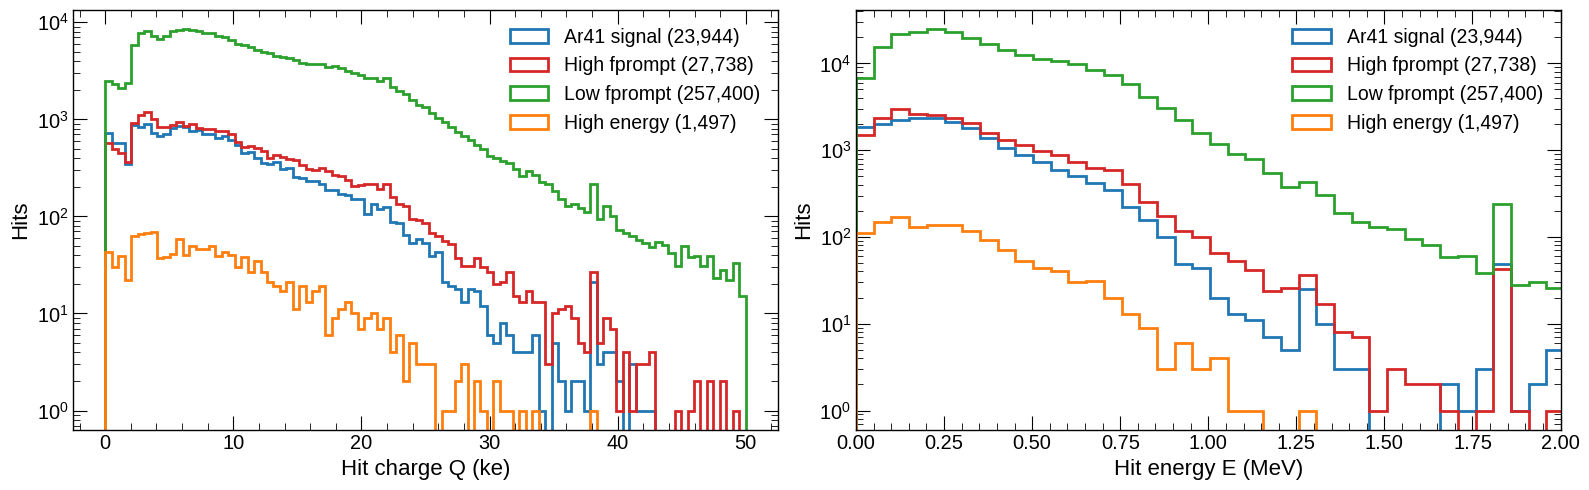

In [14]:
if regions_to_plot:
    # Q distribution by region
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    for name in regions_to_plot:
        df = charge_dfs[name]
        ax.hist(df["Q"], bins=np.linspace(0, 50, 100), histtype="step", lw=2,
                color=REGION_COLORS[name], label=f"{name} ({len(df):,})")
    ax.set_xlabel("Hit charge Q (ke)", fontsize=16)
    ax.set_ylabel("Hits", fontsize=16)
    ax.legend(fontsize=14)
    ax.set_yscale("log")

    ax = axes[1]
    for name in regions_to_plot:
        df = charge_dfs[name]
        ax.hist(df["E"], bins=np.linspace(0, 10, 200), histtype="step", lw=2,
                color=REGION_COLORS[name], label=f"{name} ({len(df):,})")
    ax.set_xlabel("Hit energy E (MeV)", fontsize=16)
    ax.set_ylabel("Hits", fontsize=16)
    ax.set_xlim(0,2)
    ax.legend(fontsize=14)
    ax.set_yscale("log")

    plt.tight_layout()
    plt.show()

<cell_type>markdown</cell_type>## Event rate vs time — half-life fitting

**Per-window rate extraction** (matching `ar41_decay.ipynb`): for each spark-free
window, flatten all trap-level fprompt/energy, count entries in each region,
divide by livetime to get rate (Hz).  Subtract cosmic background rate.

**Fit model**: single exponential A·exp(−t·ln2/τ) + C with free half-life τ.

The file-catalogue total rate (all 947 nearline files) uses a multi-exponential
model with fixed half-lives for supplementary context.

In [ ]:
# --- Cosmic background processing (light-only, for background subtraction) ---
from dtg_utils import COSMIC_DIR

N_COSMIC_FILES = 10
cosmic_files = sorted(
    os.path.join(COSMIC_DIR, f)
    for f in os.listdir(COSMIC_DIR)
    if f.endswith(".hdf5")
)[:N_COSMIC_FILES]

print(f"Processing {len(cosmic_files)} cosmic files for background ({DETECTOR.upper()}) ...")
bkg_fp_list, bkg_en_list, bkg_npe_list = [], [], []
bkg_livetime_s = 0.0
det_idx = acl_idx if DETECTOR == "acl" else lcm_idx

for cpath in cosmic_files:
    print(f"  {os.path.basename(cpath)} ...", end=" ", flush=True)
    try:
        with h5py.File(cpath, "r") as h:
            utime = h["light/events/data"]["utime_ms"]
            n_ev = len(utime)
            wvfm_ds = h["/light/wvfm/data"]["samples"]
            bkg_livetime_s += (float(utime[-1, 0]) - float(utime[0, 0])) / 1000.0

            for s in range(0, n_ev, CHUNK_SIZE):
                e = min(s + CHUNK_SIZE, n_ev)
                raw = wvfm_ds[s:e, :, :, :500]
                samp = thd_correct(raw.astype(np.float32)); del raw
                sat = reject_saturation(samp, SAT_THRESHOLD)
                tw = sum_to_traps(samp, TRAP_NAME_MAP).astype(np.float32); del samp
                fp, en = compute_fprompt_fixed(tw, PEAK_TICK_FIXED)
                npe = detect_pileup_rising_tail(
                    tw, PEAK_TICK_FIXED, PILEUP_LOOKBACK, PILEUP_TAIL_REL_HEIGHT)
                del tw
                good = ~sat
                bkg_fp_list.append(fp[good][:, det_idx])
                bkg_en_list.append(en[good][:, det_idx])
                bkg_npe_list.append(npe[good][:, det_idx])
        print(f"done ({n_ev} ev)")
    except Exception as ex:
        print(f"FAILED: {ex}")

bkg_fp_flat = np.concatenate(bkg_fp_list).ravel()
bkg_en_flat = np.concatenate(bkg_en_list).ravel()
bkg_npe_flat = np.concatenate(bkg_npe_list).ravel()
bkg_en_mev_flat = bkg_en_flat / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES

print(f"\nCosmic background: {len(bkg_fp_flat):,} trap-entries, {bkg_livetime_s:.1f} s livetime")

# Background rate per region
bkg_rates = {}
for rname, region in REGIONS.items():
    bkg_mask = in_region(bkg_fp_flat, bkg_en_mev_flat, region) & (bkg_npe_flat <= 2)
    bkg_rates[rname] = bkg_mask.sum() / bkg_livetime_s if bkg_livetime_s > 0 else 0.0
    print(f"  {rname:20s}: {bkg_mask.sum():5d} counts -> {bkg_rates[rname]:.4f} Hz")

In [ ]:
from scipy.optimize import curve_fit

def decay_model(t, A, tau, C):
    """A * exp(-t * ln2 / tau) + C  -- single exponential, free half-life."""
    return A * np.exp(-t * np.log(2) / tau) + C

# --- Map processed files to their spark-free window ---
file_to_window = {}
for label, centre in good_windows:
    lo = centre - WINDOW_HALF
    hi = centre + WINDOW_HALF
    for path in selected_979:
        if path in file_t0_979 and lo <= file_t0_979[path] < hi:
            file_to_window[path] = label

# --- Compute per-window, per-region rates (Hz), background-subtracted ---
window_labels_out = []
window_dt_arr = []
window_rates = {rname: [] for rname in REGIONS}
window_rate_errs = {rname: [] for rname in REGIONS}

for label, centre in good_windows:
    dt_min = (centre - DTG_OFF).total_seconds() / 60.0
    paths = [p for p, lbl in file_to_window.items()
             if lbl == label and p in results]
    if not paths:
        continue

    # Livetime: first-to-last event span across all files in window
    all_ts = np.concatenate([results[p]["timestamps"] for p in paths])
    livetime_s = (all_ts.max() - all_ts.min()) / 1000.0
    if livetime_s <= 0:
        continue

    # Flatten trap-level arrays for all files in this window
    fp_win = np.concatenate([results[p][f"fprompt_{DETECTOR}"].ravel() for p in paths])
    en_win = np.concatenate([results[p][f"energy_{DETECTOR}"].ravel() for p in paths])
    npe_win = np.concatenate([results[p][f"n_peaks_{DETECTOR}"].ravel() for p in paths])
    en_mev_win = en_win / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES

    window_labels_out.append(label)
    window_dt_arr.append(dt_min)

    n_ev = sum(results[p][f"fprompt_{DETECTOR}"].shape[0] for p in paths
               if results[p][f"fprompt_{DETECTOR}"].ndim == 2)

    row_parts = []
    for rname, region in REGIONS.items():
        mask = in_region(fp_win, en_mev_win, region) & (npe_win <= 2)
        count = int(mask.sum())
        bkg = bkg_rates.get(rname, 0.0)
        rate = count / livetime_s - bkg
        rate_err = np.sqrt(max(count, 1)) / livetime_s
        window_rates[rname].append(rate)
        window_rate_errs[rname].append(rate_err)
        row_parts.append(f"{count}")

    print(f"  {label}  dt={dt_min:+7.0f}min  {len(paths)}f  {livetime_s:.0f}s  "
          f"{n_ev}ev  counts=[{', '.join(row_parts)}]")

window_dt_arr = np.array(window_dt_arr)
for rname in REGIONS:
    window_rates[rname] = np.array(window_rates[rname])
    window_rate_errs[rname] = np.array(window_rate_errs[rname])

print(f"\n{len(window_dt_arr)} windows with data ({DETECTOR.upper()})")
print(f"Region order: {list(REGIONS.keys())}")

In [ ]:
# --- Total event rate vs time from file catalogue (all 947 run-979 files) ---
# Self-contained multi-exponential model (appropriate for dense catalogue data)
_ISOTOPES_CAT = {
    r"$^{41}$Ar":  {"half_life": 109.61, "color": "tab:blue"},
    r"$^{209}$Pb": {"half_life": 195.18, "color": "tab:green"},
    r"$^{64}$Cu":  {"half_life": 762.06, "color": "tab:orange"},
}
_hl_cat = np.array([v["half_life"] for v in _ISOTOPES_CAT.values()])
_lam_cat = np.log(2) / _hl_cat

def _decay_multi(t, *params):
    result = np.full_like(t, params[-1], dtype=float)
    for i, lam in enumerate(_lam_cat):
        result += params[i] * np.exp(-lam * t)
    return result

CATALOGUE_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "dtg_file_catalogue.csv")
cat_df = pd.read_csv(CATALOGUE_PATH)
cat_df["t"] = pd.to_datetime(cat_df["t_chicago"], format="ISO8601", utc=True)
cat_df["run"] = cat_df["path"].str.extract(r"rctl_(\d+)_").astype(int)

cat_979 = cat_df[cat_df["run"] == 979].sort_values("t").reset_index(drop=True)
t0_cat = cat_979["t"].iloc[0]
cat_979["t_min"] = (cat_979["t"] - t0_cat).dt.total_seconds() / 60.0

print(f"Catalogue: {len(cat_979)} run-979 files, "
      f"{cat_979['n_events'].sum():,} total events, "
      f"{cat_979['t_min'].max():.0f} min span")

# File durations from consecutive timestamps
dts = np.diff(cat_979["t_min"].values)
median_dt = float(np.median(dts))
cat_979["duration"] = np.append(dts, median_dt)
print(f"Median file duration: {median_dt:.2f} min  "
      f"(range {dts.min():.2f} - {dts.max():.2f} min)")

t_max_cat = cat_979["t_min"].max()
t_edges_cat = np.arange(0, t_max_cat + BIN_WIDTH, BIN_WIDTH)
t_centers_cat = 0.5 * (t_edges_cat[:-1] + t_edges_cat[1:])

counts_cat, _ = np.histogram(cat_979["t_min"], bins=t_edges_cat,
                              weights=cat_979["n_events"])
livetime_cat, _ = np.histogram(cat_979["t_min"], bins=t_edges_cat,
                                weights=cat_979["duration"])

rate_cat = np.where(livetime_cat > 0, counts_cat / livetime_cat, 0.0)
rate_err_cat = np.where(livetime_cat > 0, np.sqrt(counts_cat) / livetime_cat, 0.0)

valid_cat = (rate_cat > 0) & (rate_err_cat > 0)
p0 = [100.0] * len(_lam_cat) + [50.0]
popt_cat, pcov_cat = curve_fit(_decay_multi, t_centers_cat[valid_cat], rate_cat[valid_cat],
                                sigma=rate_err_cat[valid_cat], p0=p0,
                                bounds=(0, np.inf), maxfev=20000)
perr_cat = np.sqrt(np.diag(pcov_cat))

fig, ax = plt.subplots(figsize=(12, 7))
ax.errorbar(t_centers_cat, rate_cat, yerr=rate_err_cat, fmt=".", color="black",
            ms=3, alpha=0.5, label="Data (all events, file catalogue)")

t_fine_cat = np.linspace(0, t_max_cat, 1000)
ax.plot(t_fine_cat, _decay_multi(t_fine_cat, *popt_cat), "r-", lw=2, label="Total fit", zorder=5)

for i, (name, props) in enumerate(_ISOTOPES_CAT.items()):
    comp = popt_cat[i] * np.exp(-_lam_cat[i] * t_fine_cat)
    ax.plot(t_fine_cat, comp, "--", color=props["color"], lw=1.5,
            label=rf"{name}: A = {popt_cat[i]:.1f} $\pm$ {perr_cat[i]:.1f}")

ax.axhline(popt_cat[-1], color="gray", ls=":", lw=1,
           label=rf"Const = {popt_cat[-1]:.1f} $\pm$ {perr_cat[-1]:.1f}")

ax.set_xlabel("Time since start of decay run (min)", fontsize=14)
ax.set_ylabel("Event rate (events / min)", fontsize=14)
ax.set_xlim(0, 600)
ax.set_ylim(0, 6000)
ax.tick_params(direction="in", labelsize=12)
ax.legend(fontsize=11, loc="upper right")
dune_label(ax)
plt.tight_layout()
plt.show()

print("\nFit results (half-lives fixed, file catalogue):")
for i, name in enumerate(_ISOTOPES_CAT):
    print(f"  {name}: A = {popt_cat[i]:.2f} +/- {perr_cat[i]:.2f} events/min, "
          f"t1/2 = {_hl_cat[i]:.1f} min")
print(f"  Constant:  {popt_cat[-1]:.2f} +/- {perr_cat[-1]:.2f} events/min")

In [ ]:
# --- Per-region decay curves (single exponential, bkg-subtracted) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

fit_results_region = {}
for idx, (rname, region) in enumerate(REGIONS.items()):
    ax = axes.flat[idx]
    rates = window_rates[rname]
    errs = window_rate_errs[rname]

    ax.errorbar(window_dt_arr, rates, yerr=errs, fmt="o",
                color=REGION_COLORS[rname], ms=5,
                label="Data (bkg subtracted)", zorder=5)

    # Fit single exponential: A * exp(-t * ln2 / tau) + C
    fit_mask = np.isfinite(rates) & (rates > 0) & np.isfinite(errs) & (errs > 0)
    if fit_mask.sum() >= 3:
        try:
            p0 = [rates[fit_mask].max(), AR41_HALF_LIFE, 0.0]
            popt, pcov = curve_fit(
                decay_model, window_dt_arr[fit_mask], rates[fit_mask],
                sigma=errs[fit_mask], absolute_sigma=True, p0=p0,
                bounds=([0, 1, -np.inf], [np.inf, 2000, np.inf]))
            perr = np.sqrt(np.diag(pcov))
            fit_results_region[rname] = (popt, perr)

            t_fine = np.linspace(window_dt_arr.min(), window_dt_arr.max(), 500)
            ax.plot(t_fine, decay_model(t_fine, *popt), "-", color="red", lw=2,
                    label=rf"Fit: $T_{{1/2}}$ = {popt[1]:.0f} $\pm$ {perr[1]:.0f} min")
            ax.axhline(popt[2], color="gray", ls="--", lw=1,
                       label=f"C = {popt[2]:.4f} Hz")
        except RuntimeError:
            ax.text(0.5, 0.5, "Fit failed", transform=ax.transAxes,
                    ha="center", fontsize=12)

    ax.set_title(rname, fontsize=13, fontweight="bold",
                 color=REGION_COLORS[rname])
    ax.set_ylabel("Rate (Hz)", fontsize=12)
    ax.tick_params(direction="in", labelsize=11)
    ax.legend(fontsize=9, loc="upper right")

for ax in axes[1]:
    ax.set_xlabel("Time after DTG off (min)", fontsize=13)

fig.suptitle(f"Per-region decay curves -- bkg subtracted ({DETECTOR.upper()})",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print("Fit results (single exponential: A * exp(-t * ln2 / tau) + C):")
print(f"{'Region':20s} {'A (Hz)':>14s} {'tau (min)':>14s} {'C (Hz)':>14s}")
for rname, (popt, perr) in fit_results_region.items():
    print(f"{rname:20s} "
          f"{popt[0]:7.4f}+/-{perr[0]:.4f} "
          f"{popt[1]:7.0f}+/-{perr[1]:.0f} "
          f"{popt[2]:8.4f}+/-{perr[2]:.4f}")

In [ ]:
# --- Light and charge-matched event rate over time ---
window_light_rates = []
window_charge_rates = []
window_light_errs = []
window_charge_errs = []

for label, centre in good_windows:
    paths = [p for p, lbl in file_to_window.items()
             if lbl == label and p in results]
    if not paths or label not in window_labels_out:
        continue

    all_ts = np.concatenate([results[p]["timestamps"] for p in paths])
    livetime_s = (all_ts.max() - all_ts.min()) / 1000.0
    if livetime_s <= 0:
        continue

    # Total light events (non-saturated)
    n_light = sum(len(results[p]["event_indices"]) for p in paths)

    # Events with at least one charge hit
    n_charge = 0
    for p in paths:
        r = results[p]
        if len(r["charge_light_idx"]) > 0:
            matched_lids = set(int(x) for x in r["charge_light_idx"])
            n_charge += sum(1 for idx in r["event_indices"]
                            if int(idx) in matched_lids)

    window_light_rates.append(n_light / livetime_s)
    window_charge_rates.append(n_charge / livetime_s)
    window_light_errs.append(np.sqrt(max(n_light, 1)) / livetime_s)
    window_charge_errs.append(np.sqrt(max(n_charge, 1)) / livetime_s)

window_light_rates = np.array(window_light_rates)
window_charge_rates = np.array(window_charge_rates)
window_light_errs = np.array(window_light_errs)
window_charge_errs = np.array(window_charge_errs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.errorbar(window_dt_arr, window_light_rates, yerr=window_light_errs,
            fmt="o-", color="tab:blue", ms=5, label="All light events")
ax.errorbar(window_dt_arr, window_charge_rates, yerr=window_charge_errs,
            fmt="s-", color="tab:orange", ms=5, label="With charge match")
ax.set_xlabel("Time after DTG off (min)", fontsize=13)
ax.set_ylabel("Event rate (Hz)", fontsize=13)
ax.legend(fontsize=11)
ax.tick_params(direction="in", labelsize=11)
ax.set_title("Light vs charge-matched event rate", fontsize=13)
dune_label(ax)

ax = axes[1]
frac = np.where(window_light_rates > 0,
                window_charge_rates / window_light_rates, 0)
ax.plot(window_dt_arr, frac, "o-", color="tab:green", ms=5)
ax.set_xlabel("Time after DTG off (min)", fontsize=13)
ax.set_ylabel("Charge-matched fraction", fontsize=13)
ax.tick_params(direction="in", labelsize=11)
ax.set_title("Fraction of light events with charge hits", fontsize=13)
ax.set_ylim(0, 1)
dune_label(ax)

plt.tight_layout()
plt.show()

print(f"Average charge-matched fraction: {frac.mean():.2f}")

In [ ]:
# --- Charge vs Light energy spectrum comparison ---
# Collect run-979 light energy (per trap-entry) and charge energy (per hit)
light_E_979, charge_E_979 = [], []
for path in selected_979:
    if path not in results:
        continue
    r = results[path]
    en = r[f"energy_{DETECTOR}"]
    npe = r[f"n_peaks_{DETECTOR}"]
    if en.ndim == 2:
        en_mev = en / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
        good = np.isfinite(en_mev) & (npe <= 2)
        light_E_979.append(en_mev[good])
    if len(r["charge_hits"]) > 0:
        charge_E_979.append(r["charge_hits"]["E"])

light_E_979 = np.concatenate(light_E_979) if light_E_979 else np.array([])
charge_E_979 = np.concatenate(charge_E_979) if charge_E_979 else np.array([])
print(f"Run 979: {len(light_E_979):,} light trap-entries, {len(charge_E_979):,} charge hits")

# --- Per-event correlation: mean light E vs total charge E ---
ev_light_E, ev_charge_E = [], []
for path in selected_979:
    if path not in results:
        continue
    r = results[path]
    if len(r["charge_light_idx"]) == 0:
        continue

    en = r[f"energy_{DETECTOR}"]
    npe = r[f"n_peaks_{DETECTOR}"]
    if en.ndim != 2:
        continue
    en_mev = en / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
    bad = ~(np.isfinite(en_mev) & (npe <= 2))
    en_clean = np.where(bad, np.nan, en_mev)
    mean_light = np.nanmean(en_clean, axis=1)  # (n_events,)

    # Total charge E per light_id
    ch_total = pd.DataFrame({
        "lid": r["charge_light_idx"],
        "E": r["charge_hits"]["E"],
    }).groupby("lid")["E"].sum()

    ev_map = {int(idx): pos for pos, idx in enumerate(r["event_indices"])}
    for lid, tot_ch in ch_total.items():
        pos = ev_map.get(int(lid))
        if pos is not None and np.isfinite(mean_light[pos]):
            ev_light_E.append(mean_light[pos])
            ev_charge_E.append(tot_ch)

ev_light_E = np.array(ev_light_E)
ev_charge_E = np.array(ev_charge_E)
print(f"Matched events for correlation: {len(ev_light_E):,}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1D overlay (density-normalized)
E_BINS_CMP = np.arange(0, 5, 0.05)
ax = axes[0]
if len(light_E_979) > 0:
    ax.hist(light_E_979, bins=E_BINS_CMP, histtype="step", lw=2,
            color="tab:blue", label=f"Light per trap ({len(light_E_979):,})", density=True)
if len(charge_E_979) > 0:
    ax.hist(charge_E_979, bins=E_BINS_CMP, histtype="step", lw=2,
            color="tab:orange", label=f"Charge per hit ({len(charge_E_979):,})", density=True)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_xlim(0, 5)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.tick_params(direction="in", labelsize=11)
ax.set_title("Light vs charge energy spectra", fontsize=13)
dune_label(ax)

# Per-event: 2D correlation
ax = axes[1]
if len(ev_light_E) > 0:
    h = ax.hist2d(ev_light_E, ev_charge_E,
                  bins=[np.arange(0, 5, 0.05), np.arange(0, 30, 0.3)],
                  norm=LogNorm(), cmap="viridis")
    plt.colorbar(h[3], ax=ax, label="Events")
ax.set_xlabel("Mean light energy per trap (MeV)", fontsize=13)
ax.set_ylabel("Total charge energy per event (MeV)", fontsize=13)
ax.set_title(f"Per-event correlation ({len(ev_light_E):,} events)", fontsize=13)
ax.tick_params(direction="in", labelsize=11)

# Per-event: 1D comparison of event-level energies
ax = axes[2]
if len(ev_light_E) > 0:
    ax.hist(ev_light_E, bins=E_BINS_CMP, histtype="step", lw=2,
            color="tab:blue", label="Mean light E/trap", density=True)
if len(ev_charge_E) > 0:
    ax.hist(ev_charge_E, bins=np.arange(0, 30, 0.3), histtype="step", lw=2,
            color="tab:orange", label="Total charge E", density=True)
ax.set_xlabel("Energy (MeV)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.tick_params(direction="in", labelsize=11)
ax.set_title("Per-event energy distributions", fontsize=13)

plt.tight_layout()
plt.show()

## Light energy spectra and isotope decomposition

Per-region light energy spectra (trap-level), and a total energy spectrum fit
using allowed beta-decay shapes convolved with detector resolution.

**Fixed** (isotope-specific): beta endpoints, gamma energies  
**Free**: amplitudes, detector resolution widths, constant background

| Component | Decay | Visible energy range (MeV) | Note |
|-----------|-------|---------------------------|------|
| Ar-41 β only   | β⁻ → K-41* | 0 – 1.198 | γ escapes detector |
| Ar-41 β+γ      | β⁻ → K-41* → K-41 + γ | 1.294 – 2.492 | 1.294 MeV γ fully absorbed |
| Pb-209 β | β⁻ → Bi-209 | 0 – 0.644 | |
| Cu-64 β⁻ | β⁻ (38.5%) | 0 – 0.579 | |

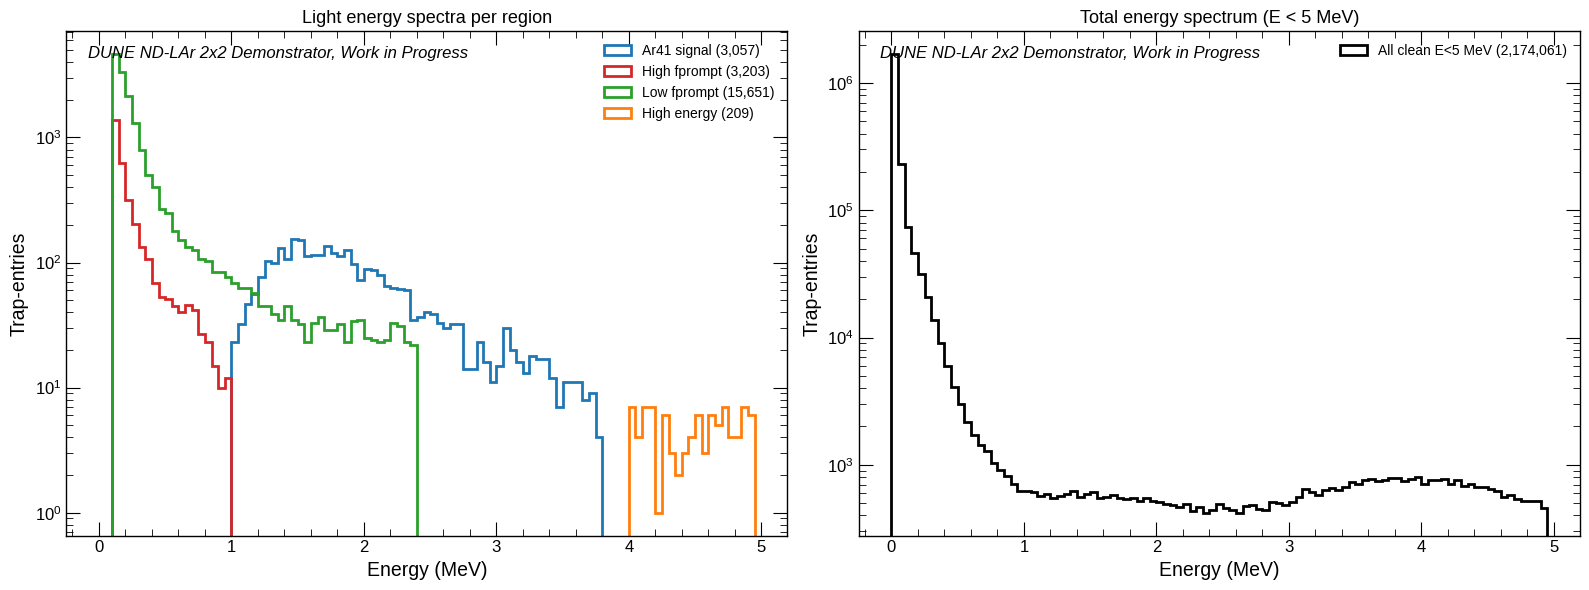

In [18]:
# --- Per-region light energy spectra ---
EN_BINS_1D = np.arange(0, 5, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: per-region overlay
ax = axes[0]
for rname in REGIONS:
    en_reg = []
    for path in selected_979:
        if path not in results:
            continue
        r = results[path]
        fp = r[f"fprompt_{DETECTOR}"]
        en = r[f"energy_{DETECTOR}"]
        npe = r[f"n_peaks_{DETECTOR}"]
        if fp.ndim != 2:
            continue
        en_mev = en / LCM_ENERGY_NORM * ENERGY_SCALE / N_MODULES
        trap_mask = in_region(fp, en_mev, REGIONS[rname]) & (npe <= 2)
        en_reg.append(en_mev[trap_mask])

    en_reg = np.concatenate(en_reg) if en_reg else np.array([])
    if len(en_reg) > 0:
        ax.hist(en_reg, bins=EN_BINS_1D, histtype="step", lw=2,
                color=REGION_COLORS[rname], label=f"{rname} ({len(en_reg):,})")

ax.set_xlabel("Energy (MeV)", fontsize=14)
ax.set_ylabel("Trap-entries", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=10)
ax.tick_params(direction="in", labelsize=12)
ax.set_title("Light energy spectra per region", fontsize=13)
dune_label(ax)

# Right: total spectrum (E < 5 MeV, excluding muons)
ax = axes[1]
muon_cut = (all_en_mev[clean] > 0) & (all_en_mev[clean] < 5)
ax.hist(all_en_mev[clean][muon_cut], bins=EN_BINS_1D, histtype="step",
        lw=2, color="black", label=f"All clean E<5 MeV ({muon_cut.sum():,})")
ax.set_xlabel("Energy (MeV)", fontsize=14)
ax.set_ylabel("Trap-entries", fontsize=14)
ax.set_yscale("log")
ax.legend(fontsize=10)
ax.tick_params(direction="in", labelsize=12)
ax.set_title("Total energy spectrum (E < 5 MeV)", fontsize=13)
dune_label(ax)

plt.tight_layout()
plt.show()

Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u207b' [U+207b], substituting with a dummy symbol.


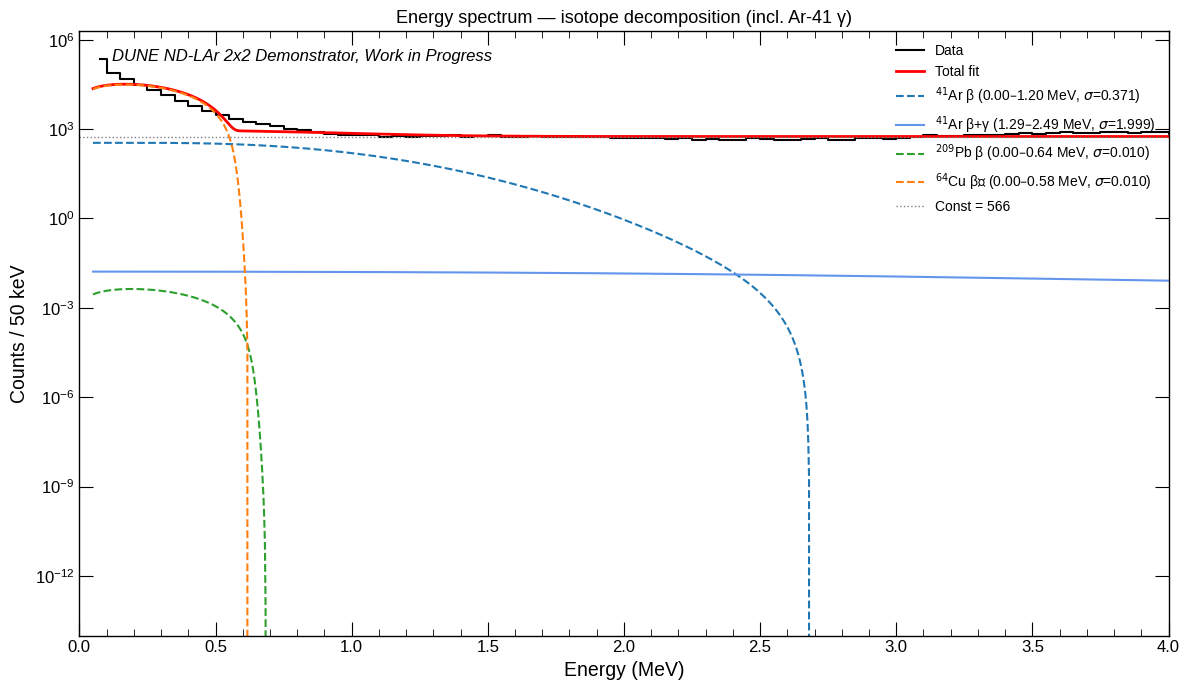


Energy fit results (endpoints and gamma energy fixed):
  $^{41}$Ar β         : A = 341 ± 2569, σ = 0.371 ± 3.096 MeV (Q=1.198)
  $^{41}$Ar β+γ       : A = 0 ± 31310, σ = 1.999 ± 437172.540 MeV (Q=1.198, shift=1.294)
  $^{209}$Pb β        : A = 0 ± 11755, σ = 0.010 ± 1773310.582 MeV (Q=0.644)
  $^{64}$Cu β⁻        : A = 10765 ± 13004, σ = 0.010 ± 0.504 MeV (Q=0.579)
  Constant            : 566 ± 5807


In [19]:
from scipy.ndimage import gaussian_filter1d

# --- Beta spectrum shape (allowed, simplified — no Fermi function) ---
def beta_shape(T, Q):
    """dN/dT ∝ p_e · E_e · (Q - T)^2  for kinetic energy T, endpoint Q."""
    m_e = 0.511  # MeV
    E_e = T + m_e
    p_e = np.sqrt(np.maximum(E_e**2 - m_e**2, 0))
    return p_e * E_e * np.maximum(Q - T, 0)**2

# Fine energy grid for convolution
E_fine = np.arange(0, 5, 0.001)
dE_fine = E_fine[1] - E_fine[0]

AR41_GAMMA = 1.294   # MeV — gamma from K-41* de-excitation
AR41_Q_BETA = 1.198  # MeV — beta endpoint to excited state

# Fit components: each has a beta endpoint Q and an energy shift
# "shift" accounts for the gamma being absorbed (adds to visible energy)
COMPONENTS = [
    {"name": r"$^{41}$Ar β",      "Q": AR41_Q_BETA, "shift": 0,          "color": "tab:blue",   "ls": "--"},
    {"name": r"$^{41}$Ar β+γ",    "Q": AR41_Q_BETA, "shift": AR41_GAMMA, "color": "cornflowerblue", "ls": "-"},
    {"name": r"$^{209}$Pb β",     "Q": 0.644,       "shift": 0,          "color": "tab:green",  "ls": "--"},
    {"name": r"$^{64}$Cu β⁻",     "Q": 0.579,       "shift": 0,          "color": "tab:orange", "ls": "--"},
]
n_comp = len(COMPONENTS)

def make_template(Q, sigma, shift=0):
    """Smeared beta spectrum template, optionally shifted by gamma energy.
    Normalized to unit area."""
    T = E_fine - shift  # kinetic energy of the beta
    raw = np.where(T >= 0, beta_shape(T, Q), 0.0)
    if sigma > 0.005:
        raw = gaussian_filter1d(raw, sigma / dE_fine)
    area = raw.sum() * dE_fine
    return raw / area if area > 0 else raw

# Fit model: sum of smeared (shifted) betas + constant
# params: [A_0, σ_0, A_1, σ_1, ..., A_n, σ_n, C]
def energy_model(E, *params):
    result = np.full_like(E, params[-1], dtype=float)
    for i, comp in enumerate(COMPONENTS):
        A = params[2 * i]
        sigma = params[2 * i + 1]
        tmpl = make_template(comp["Q"], max(sigma, 0.005), comp["shift"])
        result += A * np.interp(E, E_fine, tmpl)
    return result

# Histogram the data (0–5 MeV, excluding muons)
en_fit = all_en_mev[clean]
en_fit = en_fit[(en_fit > 0.05) & (en_fit < 5)]
bin_edges_fit = np.arange(0.05, 5, 0.05)
bin_centers_fit = 0.5 * (bin_edges_fit[:-1] + bin_edges_fit[1:])
counts_fit, _ = np.histogram(en_fit, bins=bin_edges_fit)
counts_err = np.sqrt(np.maximum(counts_fit, 1))

# Fit
valid_fit = counts_fit > 0
p0_en = [5e4, 0.3] * n_comp + [100]
bounds_lo = [0, 0.01] * n_comp + [0]
bounds_hi = [np.inf, 2.0] * n_comp + [np.inf]

try:
    popt_en, pcov_en = curve_fit(
        energy_model, bin_centers_fit[valid_fit], counts_fit[valid_fit],
        sigma=counts_err[valid_fit], p0=p0_en,
        bounds=(bounds_lo, bounds_hi), maxfev=50000)
    perr_en = np.sqrt(np.diag(pcov_en))
    en_fit_ok = True
except RuntimeError as e:
    print(f"Energy fit did not converge: {e}")
    en_fit_ok = False

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))
ax.step(bin_centers_fit, counts_fit, where="mid", color="black", lw=1.5, label="Data")

if en_fit_ok:
    E_plot = np.linspace(0.05, 5, 2000)
    ax.plot(E_plot, energy_model(E_plot, *popt_en), "r-", lw=2, label="Total fit")

    for i, comp in enumerate(COMPONENTS):
        A = popt_en[2 * i]
        sig = popt_en[2 * i + 1]
        tmpl = make_template(comp["Q"], max(sig, 0.005), comp["shift"])
        component = A * np.interp(E_plot, E_fine, tmpl)
        erange = f"{comp['shift']:.2f}–{comp['shift']+comp['Q']:.2f}"
        ax.plot(E_plot, component, comp["ls"], color=comp["color"], lw=1.5,
                label=rf"{comp['name']} ({erange} MeV, $\sigma$={sig:.3f})")

    ax.axhline(popt_en[-1], color="gray", ls=":", lw=1,
               label=f"Const = {popt_en[-1]:.0f}")

ax.set_xlabel("Energy (MeV)", fontsize=14)
ax.set_ylabel("Counts / 50 keV", fontsize=14)
ax.set_yscale("log")
ax.set_xlim(0, 4)
ax.tick_params(direction="in", labelsize=12)
ax.legend(fontsize=10, loc="upper right")
dune_label(ax)
ax.set_title("Energy spectrum — isotope decomposition (incl. Ar-41 γ)", fontsize=13)
plt.tight_layout()
plt.show()

if en_fit_ok:
    print("\nEnergy fit results (endpoints and gamma energy fixed):")
    for i, comp in enumerate(COMPONENTS):
        shift_str = f", shift={comp['shift']:.3f}" if comp["shift"] > 0 else ""
        print(f"  {comp['name']:20s}: A = {popt_en[2*i]:.0f} ± {perr_en[2*i]:.0f}, "
              f"σ = {popt_en[2*i+1]:.3f} ± {perr_en[2*i+1]:.3f} MeV "
              f"(Q={comp['Q']:.3f}{shift_str})")
    print(f"  {'Constant':20s}: {popt_en[-1]:.0f} ± {perr_en[-1]:.0f}")